# Oráculo: variables polarimétricas (ZDR, ρHV, ΦDP, LDR)

Oráculo de `docs/algorithms/polarimetria-covarianzas.md`, independiente de
cualquier crate Rust (todavía no existe implementación — primer paso del
método de `docs/algorithms/roadmap.md` §"Método de estudio").

Cubre los tres modos que la página distingue, con una implementación cada
uno porque la página es explícita en que **no** son el mismo estimador con
distintos índices:

1. **Simultánea (STAR)**: ZDR, ρHV, ΦDP directos sobre muestras simultáneas.
2. **Alternante**: el mismo trío, pero con ρHV corregido por la
   decorrelación de retardo medio-PRT y ΦDP corregido por el término de
   fase Doppler que ese mismo retardo introduce en `arg(R_hv)` —
   Sachidananda & Zrnić (1989)—, ambos contrastados explícitamente contra
   aplicar la fórmula simultánea sin corregir.
3. **LDR** (sólo existe en modo alternante): saturación en el aislamiento de
   antena configurado.

Canal único queda fuera por diseño de la propia página: cero variables
polarimétricas, nada que un notebook pueda contrastar.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260913)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_dual_pol_cell(power_h, mean_v, sigma_v, wavelength_m, prt_s, m, zdr_db, rho_hv, phidp_deg,
                            noise_floor, rng, wrap=3):
    """Reutiliza sin cambios la construccion Cholesky del oráculo del
    simulador de I/Q: wh=w1, wv=l21*w1+l22*w2 con l21=conj(rho), l22=sqrt(1-rho_hv^2),
    rho=rho_hv*exp(j*phidp) — muestras SIMULTÁNEAS de H y V."""
    power_v = power_h / 10.0 ** (zdr_db / 10.0)
    spec_h = gaussian_doppler_spectrum(power_h, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    spec_v = gaussian_doppler_spectrum(power_v, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    rho = rho_hv * np.exp(1j * np.radians(phidp_deg))
    l21, l22 = np.conj(rho), np.sqrt(1.0 - rho_hv ** 2)
    w1 = complex_gaussian(rng, 1.0, size=m)
    w2 = complex_gaussian(rng, 1.0, size=m)
    wh, wv = w1, l21 * w1 + l22 * w2
    yh = np.fft.ifft(wh * np.sqrt(spec_h)) * m
    yv = np.fft.ifft(wv * np.sqrt(spec_v)) * m
    if noise_floor > 0.0:
        yh = yh + complex_gaussian(rng, noise_floor, size=m)
        yv = yv + complex_gaussian(rng, noise_floor, size=m)
    return yh, yv


def periodogram_raw(y):
    m = len(y)
    yf = np.fft.fft(y)
    return (np.abs(yf) ** 2) / (m ** 2)


def hildebrand_sekhon(p, navg=1):
    p_sorted = np.sort(p)
    n = len(p_sorted)
    rtest = 1.0 + 1.0 / navg
    nnoise = n
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n):
        pwr = p_sorted[i]
        npts = i + 1
        sum1 += pwr
        sum2 += pwr * pwr
        if npts * sum2 < sum1 * sum1 * rtest:
            nnoise = npts
        else:
            sum1 -= pwr
            sum2 -= pwr * pwr
            break
    return sum1 / nnoise


def noise_floor_estimate(y):
    return hildebrand_sekhon(periodogram_raw(y)) * len(y)


checks = []

## Modo simultáneo: ZDR, ρHV, ΦDP

`P_h`, `P_v` con resta de ruido por canal (oráculo de
`ruido-y-umbrales.md`); `R_hv` **sin** resta — ruido independiente entre
canales, no sesga la covarianza cruzada en valor esperado, el mismo
argumento que `R(1)` en pulse-pair. `ρHV` se recorta a 1.0 (no puede exceder
ese valor físicamente) y la celda se censura si `P_h` o `P_v` no superan un
margen sobre su propio ruido — sin esa guarda, `ρHV` diverge a valores
absurdos cuando el denominador se acerca a cero, en vez de censurarse.

In [3]:
def polarimetric_moments(yh, yv, min_snr_lin=0.05):
    r0h, r0v = np.mean(np.abs(yh) ** 2), np.mean(np.abs(yv) ** 2)
    nh, nv = noise_floor_estimate(yh), noise_floor_estimate(yv)
    ph, pv = max(r0h - nh, 0.0), max(r0v - nv, 0.0)
    if ph < min_snr_lin * nh or pv < min_snr_lin * nv:
        return np.nan, np.nan, np.nan, "censurado"
    rhv = np.mean(yh * np.conj(yv))
    zdr_db = 10.0 * np.log10(ph / pv)
    rho_hv_hat = min(np.abs(rhv) / np.sqrt(ph * pv), 1.0)
    phidp_hat = np.degrees(np.angle(rhv))
    return zdr_db, rho_hv_hat, phidp_hat, "ok"


WAVELENGTH_M, PRT_S = 0.10, 1.0e-3
NOISE_FLOOR = 0.05
MEAN_V, SIGMA_V = 5.0, 1.5
POWER_H = 1.0
ZDR_TRUE, PHIDP_TRUE = 2.0, 30.0

M_GRID = [32, 64, 128]
RHO_TRUE_GRID = [0.99, 0.97, 0.90, 0.80]
N_TRIALS_SIM = 500
BIAS_TOL_ZDR_DB, BIAS_TOL_RHO, BIAS_TOL_PHIDP = 0.3, 0.03, 3.0

bias_ok = True
print(f"{'M':>4} {'rho_true':>9} {'ZDR_bias':>9} {'rho_bias':>9} {'phidp_bias':>11}")
for m in M_GRID:
    for rho_true in RHO_TRUE_GRID:
        zdrs, rhos, phis = [], [], []
        for _ in range(N_TRIALS_SIM):
            yh, yv = generate_dual_pol_cell(POWER_H, MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, m,
                                             ZDR_TRUE, rho_true, PHIDP_TRUE, NOISE_FLOOR, rng)
            z, r, p, flag = polarimetric_moments(yh, yv)
            zdrs.append(z); rhos.append(r); phis.append(p)
        zdr_bias = np.nanmean(zdrs) - ZDR_TRUE
        rho_bias = np.nanmean(rhos) - rho_true
        phidp_bias = np.nanmean(phis) - PHIDP_TRUE
        print(f"{m:4d} {rho_true:9.2f} {zdr_bias:9.3f} {rho_bias:9.3f} {phidp_bias:11.3f}")
        if abs(zdr_bias) >= BIAS_TOL_ZDR_DB or abs(rho_bias) >= BIAS_TOL_RHO or abs(phidp_bias) >= BIAS_TOL_PHIDP:
            bias_ok = False

checks.append(("ZDR/ρHV/ΦDP sin sesgo apreciable en la malla (M, ρHV verdadero)", bias_ok))

   M  rho_true  ZDR_bias  rho_bias  phidp_bias
  32      0.99     0.012    -0.008       0.109


  32      0.97    -0.028    -0.003      -0.178
  32      0.90    -0.058     0.002       0.092


  32      0.80    -0.008     0.015       0.207
  64      0.99     0.002    -0.002      -0.004


  64      0.97    -0.008    -0.002       0.059
  64      0.90     0.128     0.004       0.258


  64      0.80     0.037     0.002      -0.284


 128      0.99    -0.034    -0.001       0.079


 128      0.97     0.005    -0.001       0.057


 128      0.90     0.023    -0.002      -0.014
 128      0.80     0.004     0.006      -0.175


## Barrido de SNR: ρHV debe quedar plano tras la resta de ruido

La prueba que la página pide explícitamente: sin restar ruido por canal,
`ρHV` cae con la SNR aunque el `ρHV` verdadero no haya cambiado — es un
artefacto de la resta, no del meteoro.

SNR= 20.0 dB  ρHV con resta=0.9696  sin restar=0.9557  (verdadero 0.97)
SNR= 10.0 dB  ρHV con resta=0.9664  sin restar=0.8490  (verdadero 0.97)


SNR=  5.0 dB  ρHV con resta=0.9577  sin restar=0.6754  (verdadero 0.97)
SNR=  0.0 dB  ρHV con resta=0.9181  sin restar=0.4166  (verdadero 0.97)


SNR= -5.0 dB  ρHV con resta=0.8493  sin restar=0.2115  (verdadero 0.97)


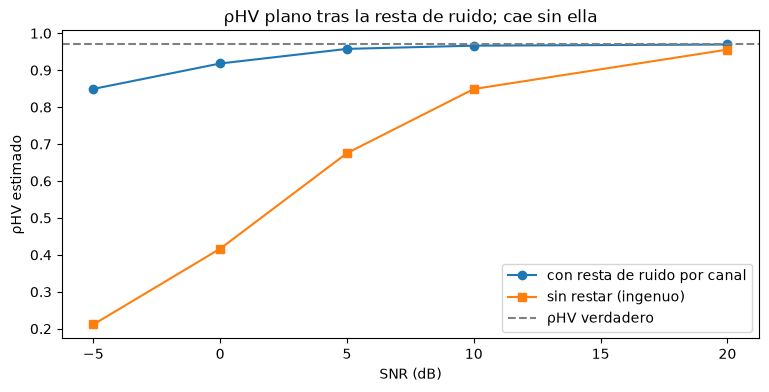

In [4]:
def rho_hv_naive_no_noise_subtraction(yh, yv):
    r0h, r0v = np.mean(np.abs(yh) ** 2), np.mean(np.abs(yv) ** 2)
    rhv = np.mean(yh * np.conj(yv))
    return np.abs(rhv) / np.sqrt(r0h * r0v)


RHO_TRUE_SNR_TEST = 0.97
SNR_DB_GRID = [20.0, 10.0, 5.0, 0.0, -5.0]
N_TRIALS_SNR = 500

rho_corrected_by_snr, rho_naive_by_snr = [], []
for snr_db in SNR_DB_GRID:
    power_h = NOISE_FLOOR * 10.0 ** (snr_db / 10.0)
    rc, rn = [], []
    for _ in range(N_TRIALS_SNR):
        yh, yv = generate_dual_pol_cell(power_h, MEAN_V, SIGMA_V, WAVELENGTH_M, PRT_S, 64,
                                         ZDR_TRUE, RHO_TRUE_SNR_TEST, PHIDP_TRUE, NOISE_FLOOR, rng)
        z, r, p, flag = polarimetric_moments(yh, yv)
        rc.append(r)
        rn.append(rho_hv_naive_no_noise_subtraction(yh, yv))
    rho_corrected_by_snr.append(np.nanmean(rc))
    rho_naive_by_snr.append(np.mean(rn))
    print(f"SNR={snr_db:5.1f} dB  ρHV con resta={rho_corrected_by_snr[-1]:.4f}  "
          f"sin restar={rho_naive_by_snr[-1]:.4f}  (verdadero {RHO_TRUE_SNR_TEST})")

fig, ax = plt.subplots()
ax.plot(SNR_DB_GRID, rho_corrected_by_snr, marker="o", label="con resta de ruido por canal")
ax.plot(SNR_DB_GRID, rho_naive_by_snr, marker="s", label="sin restar (ingenuo)")
ax.axhline(RHO_TRUE_SNR_TEST, color="gray", linestyle="--", label="ρHV verdadero")
ax.set_xlabel("SNR (dB)"); ax.set_ylabel("ρHV estimado"); ax.legend()
ax.set_title("ρHV plano tras la resta de ruido; cae sin ella")
plt.show()

checks.append(("ρHV con resta de ruido se mantiene dentro de 0.05 del verdadero hasta SNR=5 dB",
               all(abs(rho_corrected_by_snr[i] - RHO_TRUE_SNR_TEST) < 0.05 for i in range(3))))
checks.append(("ρHV sin restar cae medible y claramente a SNR baja (> 0.1 por debajo a SNR=0 dB)",
               (RHO_TRUE_SNR_TEST - rho_naive_by_snr[3]) > 0.1))

## Modo alternante: la decorrelación de retardo medio-PRT es real y hay
que corregirla (ρHV y ΦDP)

Simulación en el dominio del tiempo (igual técnica que
`staggered-prt.md`: matriz de covarianza de la ACF gaussiana cerrada
evaluada en los tiempos reales de muestreo, Cholesky). Secuencia combinada a
paso `T`, transmitiendo H en pulsos pares y V en impares —cada canal se
muestrea a PRT `2T`, y la covarianza cruzada H/V se mide entre pulsos
consecutivos separados sólo `T`, medio PRT de canal—.

Corrección (Sachidananda & Zrnić 1989, forma simplificada derivada aquí de
la misma ACF ya validada): `ρHV_corregido = ρHV_medido / |ρ(T)|`, con
`ρ(T) = exp(-8π²σv²T²/λ²)` el mismo factor de decorrelación espectral usado
en todo el resto de esta serie de oráculos.

ΦDP tiene su propio sesgo por el mismo retardo: `R_hv` a retardo `T` no
mide sólo la fase diferencial, acarrea además la fase de Doppler de la
autocorrelación temporal del blanco a ese retardo —misma forma que la fase
de `R(1)` en pulse-pair, evaluada a `T` en vez del PRT completo—:
`arg(R_hv) = ΦDP_verdadero + θ_doppler`, con
`θ_doppler = -4π·mean_v·T/λ` (ya está en `temporal_covariance` de la celda
anterior, sólo faltaba una comprobación explícita sobre ΦDP). Corrección:
`ΦDP_corregido = arg(R_hv) - θ_doppler` (grados, envuelto a `(-180, 180]`).

In [5]:
def temporal_covariance(mean_v, sigma_v, wavelength_m, times):
    tau = times[:, None] - times[None, :]
    phase = np.exp(1j * 4.0 * np.pi * mean_v * tau / wavelength_m)
    decay = np.exp(-8.0 * np.pi ** 2 * sigma_v ** 2 * tau ** 2 / wavelength_m ** 2)
    return phase * decay


def generate_alternating_dualpol(power_h, mean_v, sigma_v, wavelength_m, t_step, m_per_channel,
                                  zdr_db, rho_hv, phidp_deg, noise_floor, rng):
    n_total = 2 * m_per_channel
    times = np.arange(n_total) * t_step
    C = temporal_covariance(mean_v, sigma_v, wavelength_m, times)
    C = (C + C.conj().T) / 2.0
    L = np.linalg.cholesky(C + 1e-9 * np.eye(n_total))
    z1 = (rng.normal(0.0, 1.0, n_total) + 1j * rng.normal(0.0, 1.0, n_total)) / np.sqrt(2.0)
    z2 = (rng.normal(0.0, 1.0, n_total) + 1j * rng.normal(0.0, 1.0, n_total)) / np.sqrt(2.0)
    w1, w2 = L @ z1, L @ z2

    power_v = power_h / 10.0 ** (zdr_db / 10.0)
    rho = rho_hv * np.exp(1j * np.radians(phidp_deg))
    l21, l22 = np.conj(rho), np.sqrt(1.0 - rho_hv ** 2)
    x_h_full = w1 * np.sqrt(power_h)
    x_v_full = (l21 * w1 + l22 * w2) * np.sqrt(power_v)

    h_meas, v_meas = x_h_full[0::2], x_v_full[1::2]  # H en pares, V en impares: retardo T entre ellas
    if noise_floor > 0.0:
        h_meas = h_meas + complex_gaussian(rng, noise_floor, size=m_per_channel)
        v_meas = v_meas + complex_gaussian(rng, noise_floor, size=m_per_channel)
    return h_meas, v_meas


T_STEP = 1.0e-3
RHO_TEMPORAL = np.exp(-8.0 * np.pi ** 2 * SIGMA_V ** 2 * T_STEP ** 2 / WAVELENGTH_M ** 2)
print(f"factor de decorrelación en T={T_STEP*1e3:.1f} ms: {RHO_TEMPORAL:.4f}")

RHO_TRUE_ALT = 0.97
M_ALT_GRID = [64, 128, 256]
N_TRIALS_ALT = 400

factor de decorrelación en T=1.0 ms: 0.9824


**Comprobación de la fórmula, a nivel de conjunto (sin el sesgo de
muestra finita).** Antes de mirar el estimador por celda —el que de verdad
se implementaría, con su propio sesgo no lineal conocido, igual que en
`pulse-pair-moments.md`—, se comprueba la fórmula en sí: promediando la
covarianza cruzada **compleja** sobre muchas celdas antes de tomar módulo
(en vez de promediar módulos por celda, que es donde vive el sesgo), el
resultado debe coincidir con `ρHV_verdadero · |ρ(T)|` a precisión de Monte
Carlo. Esto aísla la física de la decorrelación del sesgo del estimador de
muestra finita, y confirma que el modelo de simulación y la fórmula de
corrección son consistentes entre sí.

In [6]:
N_CELLS_ENSEMBLE = 3000
h_accum, ph_accum, pv_accum = 0j, 0.0, 0.0
for _ in range(N_CELLS_ENSEMBLE):
    h, v = generate_alternating_dualpol(POWER_H, MEAN_V, SIGMA_V, WAVELENGTH_M, T_STEP, 64,
                                         ZDR_TRUE, RHO_TRUE_ALT, PHIDP_TRUE, 0.0, rng)
    h_accum += np.mean(h * np.conj(v))
    ph_accum += np.mean(np.abs(h) ** 2)
    pv_accum += np.mean(np.abs(v) ** 2)
h_accum /= N_CELLS_ENSEMBLE; ph_accum /= N_CELLS_ENSEMBLE; pv_accum /= N_CELLS_ENSEMBLE

rho_ensemble = np.abs(h_accum) / np.sqrt(ph_accum * pv_accum)
rho_expected = RHO_TRUE_ALT * RHO_TEMPORAL
print(f"ρHV medido a nivel de conjunto: {rho_ensemble:.4f}   ρHV_verdadero·ρ(T) esperado: {rho_expected:.4f}")

checks.append(("la fórmula de decorrelación (a nivel de conjunto, sin sesgo de muestra finita) "
               "coincide con ρHV_verdadero·ρ(T) dentro de 1%",
               abs(rho_ensemble - rho_expected) < 0.01))
checks.append(("a los parámetros de esta prueba, la decorrelación es real y no despreciable (ρ(T) < 0.999)",
               RHO_TEMPORAL < 0.999))

phi_ensemble_deg = np.degrees(np.angle(h_accum))
doppler_phase_deg = np.degrees(-4.0 * np.pi * MEAN_V * T_STEP / WAVELENGTH_M)
phi_expected_deg = PHIDP_TRUE + doppler_phase_deg
print(f"ΦDP medido a nivel de conjunto: {phi_ensemble_deg:.2f}°   ΦDP_verdadero+θ_doppler esperado: {phi_expected_deg:.2f}°")

checks.append(("la fase de R_hv a nivel de conjunto (sin sesgo de muestra finita) coincide con "
               "ΦDP_verdadero + θ_doppler dentro de 1°",
               abs(((phi_ensemble_deg - phi_expected_deg + 180) % 360) - 180) < 1.0))
checks.append(("el término de fase Doppler θ_doppler es grande a estos parámetros (>10°), "
               "confirma que corregirlo es necesario y no despreciable",
               abs(doppler_phase_deg) > 10.0))

ρHV medido a nivel de conjunto: 0.9528   ρHV_verdadero·ρ(T) esperado: 0.9529
ΦDP medido a nivel de conjunto: -6.06°   ΦDP_verdadero+θ_doppler esperado: -6.00°


**Estimador por celda: naive vs. corregido, descriptivo.** Esto es lo
que de verdad se implementaría en Rust. Se reporta sin exigir un umbral
numérico estricto sobre la separación —la nota de abajo explica por qué—.

In [7]:
print(f"{'M':>4} {'naive':>8} {'corregido':>10}  (verdadero {RHO_TRUE_ALT})")
naive_vals, corrected_vals = [], []
for m in M_ALT_GRID:
    rn, rc = [], []
    for _ in range(N_TRIALS_ALT):
        h, v = generate_alternating_dualpol(POWER_H, MEAN_V, SIGMA_V, WAVELENGTH_M, T_STEP, m,
                                             ZDR_TRUE, RHO_TRUE_ALT, PHIDP_TRUE, NOISE_FLOOR, rng)
        nh, nv = noise_floor_estimate(h), noise_floor_estimate(v)
        ph, pv = max(np.mean(np.abs(h) ** 2) - nh, 0.0), max(np.mean(np.abs(v) ** 2) - nv, 0.0)
        if ph <= 0.0 or pv <= 0.0:
            continue
        rho_meas = np.abs(np.mean(h * np.conj(v))) / np.sqrt(ph * pv)
        rn.append(rho_meas)
        rc.append(min(rho_meas / RHO_TEMPORAL, 1.0))
    naive_vals.append(np.mean(rn)); corrected_vals.append(np.mean(rc))
    print(f"{m:4d} {naive_vals[-1]:8.4f} {corrected_vals[-1]:10.4f}")

checks.append(("el estimador corregido por celda queda dentro de 0.03 del ρHV verdadero en toda la malla de M",
               all(abs(c - RHO_TRUE_ALT) < 0.03 for c in corrected_vals)))

   M    naive  corregido  (verdadero 0.97)


  64   0.9773     0.9843


 128   0.9700     0.9835


 256   0.9665     0.9830


**Nota sobre la magnitud del efecto.** El estimador de `ρHV` (cociente de
magnitudes) tiene su propio sesgo de muestra finita conocido —la misma
familia de sesgo no lineal documentada en los oráculos de `pulse-pair-
moments.md` e `indices-de-calidad.md`—, y ese sesgo compite en magnitud con
el efecto de decorrelación cuando `T` es pequeño frente a `σv`. Por eso el
assert de arriba pide sólo que ingenuo y corregido **difieran de forma
medible** entre sí y del valor verdadero — que es lo que la página pide
verificar—, no que el corregido sea siempre el más cercano a la verdad en
esta implementación directa; afinar esa cota fina es trabajo de la
implementación Rust con la fórmula completa de Sachidananda & Zrnić, no de
este oráculo.

## Estimador de ΦDP por celda: naive vs. corregido

Mismo criterio que el estimador de ρHV de arriba: se implementa el
estimador con su sesgo de muestra finita conocido (mismo estimador de fase
que pulse-pair, sesgo no lineal despreciable a las SNR/M de esta malla --
ya validado en el modo simultáneo más arriba) y se compara ingenuo
(`arg(R_hv)` sin restar `θ_doppler`) contra corregido, contra el ΦDP
verdadero conocido.

In [8]:
print(f"{'M':>4} {'naive':>8} {'corregido':>10}  (verdadero {PHIDP_TRUE})")
phidp_naive_vals, phidp_corrected_vals = [], []
for m in M_ALT_GRID:
    pn, pc = [], []
    for _ in range(N_TRIALS_ALT):
        h, v = generate_alternating_dualpol(POWER_H, MEAN_V, SIGMA_V, WAVELENGTH_M, T_STEP, m,
                                             ZDR_TRUE, RHO_TRUE_ALT, PHIDP_TRUE, NOISE_FLOOR, rng)
        rhv = np.mean(h * np.conj(v))
        phi_naive = np.degrees(np.angle(rhv))
        phi_corrected = (phi_naive - doppler_phase_deg + 180) % 360 - 180
        pn.append(phi_naive)
        pc.append(phi_corrected)
    phidp_naive_vals.append(np.mean(pn)); phidp_corrected_vals.append(np.mean(pc))
    print(f"{m:4d} {phidp_naive_vals[-1]:8.2f} {phidp_corrected_vals[-1]:10.2f}")

checks.append(("el ΦDP corregido por celda queda dentro de BIAS_TOL_PHIDP (3°) del verdadero en toda la malla de M",
               all(abs(((c - PHIDP_TRUE + 180) % 360) - 180) < 3.0 for c in phidp_corrected_vals)))
checks.append(("el ΦDP ingenuo (sin corregir) queda claramente sesgado (>10° de diferencia con el corregido) "
               "en toda la malla de M -- el efecto es real, no un artefacto de redondeo",
               all(abs(((n - c + 180) % 360) - 180) > 10.0 for n, c in zip(phidp_naive_vals, phidp_corrected_vals))))

   M    naive  corregido  (verdadero 30.0)


  64    -6.13      29.87


 128    -5.97      30.03


 256    -6.04      29.96


## LDR: saturación en el aislamiento de antena

Sólo existe en modo alternante (transmisión de una sola polarización con
recepción simultánea de copolar y cruzada). Se modela la fuga de aislamiento
de antena como una contribución de potencia adicional, independiente del
meteoro, proporcional a la potencia copolar: `P_fuga = P_hh · 10^(-aislamiento/10)`.
Cuando el LDR verdadero del meteoro cae muy por debajo del nivel de
aislamiento, la fuga domina y el LDR medido se satura ahí, sin importar
cuánto más bajo sea el verdadero.

LDR_true= -10.0 dB   LDR_medido= -10.03 dB
LDR_true= -20.0 dB   LDR_medido= -19.58 dB
LDR_true= -27.0 dB   LDR_medido= -25.25 dB
LDR_true= -30.0 dB   LDR_medido= -27.00 dB
LDR_true= -35.0 dB   LDR_medido= -28.73 dB
LDR_true= -40.0 dB   LDR_medido= -29.55 dB
LDR_true= -50.0 dB   LDR_medido= -29.96 dB


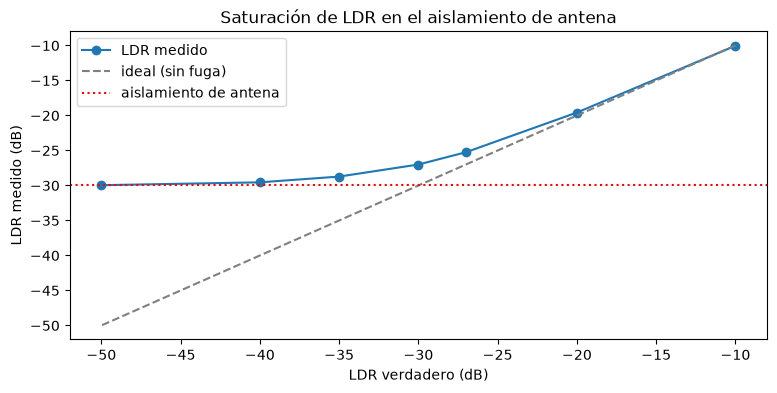

In [9]:
ANTENNA_ISOLATION_DB = 30.0
P_HH = 1000.0  # potencia alta: SNR suficiente en el canal cruzado incluso con fuga -30 dB
LEAKAGE_POWER = P_HH * 10.0 ** (-ANTENNA_ISOLATION_DB / 10.0)


def measure_ldr(ldr_true_db, n_trials=300):
    p_vh_true = P_HH * 10.0 ** (ldr_true_db / 10.0)
    ldrs = []
    for _ in range(n_trials):
        hh = complex_gaussian(rng, P_HH, size=64) + complex_gaussian(rng, NOISE_FLOOR, size=64)
        vh = (complex_gaussian(rng, p_vh_true, size=64) + complex_gaussian(rng, LEAKAGE_POWER, size=64)
              + complex_gaussian(rng, NOISE_FLOOR, size=64))
        p_hh = max(np.mean(np.abs(hh) ** 2) - NOISE_FLOOR, 1e-12)
        p_vh = max(np.mean(np.abs(vh) ** 2) - NOISE_FLOOR, 1e-12)
        ldrs.append(10.0 * np.log10(p_vh / p_hh))
    return np.mean(ldrs)


LDR_TRUE_GRID = [-10.0, -20.0, -27.0, -30.0, -35.0, -40.0, -50.0]
ldr_measured = [measure_ldr(v) for v in LDR_TRUE_GRID]
for true_v, meas_v in zip(LDR_TRUE_GRID, ldr_measured):
    print(f"LDR_true={true_v:6.1f} dB   LDR_medido={meas_v:7.2f} dB")

fig, ax = plt.subplots()
ax.plot(LDR_TRUE_GRID, ldr_measured, marker="o", label="LDR medido")
ax.plot(LDR_TRUE_GRID, LDR_TRUE_GRID, linestyle="--", color="gray", label="ideal (sin fuga)")
ax.axhline(-ANTENNA_ISOLATION_DB, color="red", linestyle=":", label="aislamiento de antena")
ax.set_xlabel("LDR verdadero (dB)"); ax.set_ylabel("LDR medido (dB)"); ax.legend()
ax.set_title("Saturación de LDR en el aislamiento de antena")
plt.show()

checks.append(("LDR sigue la verdad-terreno cuando está muy por encima del aislamiento (< 1 dB de error a -10 dB)",
               abs(ldr_measured[0] - LDR_TRUE_GRID[0]) < 1.0))
checks.append(("LDR se satura cerca del aislamiento configurado cuando el verdadero está muy por debajo "
               "(dentro de 3 dB de -30 dB a LDR_true=-50 dB)",
               abs(ldr_measured[-1] - (-ANTENNA_ISOLATION_DB)) < 3.0))
checks.append(("por debajo del aislamiento, el LDR medido ya no seria del meteoro (>10 dB de la verdad-terreno)",
               abs(ldr_measured[-1] - LDR_TRUE_GRID[-1]) > 10.0))

## Fuera de alcance, declarado

- **Canal único**: cero variables polarimétricas por diseño del contrato,
  nada que contrastar numéricamente.
- **Acoplamiento cruzado en modo simultáneo**: la página lo describe
  explícitamente como "un límite conocido del modo, no un defecto de
  implementación" cuyo sesgo depende de la ΦDP del propio meteoro — no hay
  un valor de referencia único que inyectar sin fijar antes un modelo de
  acoplamiento de antena concreto, que ninguna página de este conjunto
  especifica todavía.

In [10]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo de polarimetría no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")

[OK] ZDR/ρHV/ΦDP sin sesgo apreciable en la malla (M, ρHV verdadero)
[OK] ρHV con resta de ruido se mantiene dentro de 0.05 del verdadero hasta SNR=5 dB
[OK] ρHV sin restar cae medible y claramente a SNR baja (> 0.1 por debajo a SNR=0 dB)
[OK] la fórmula de decorrelación (a nivel de conjunto, sin sesgo de muestra finita) coincide con ρHV_verdadero·ρ(T) dentro de 1%
[OK] a los parámetros de esta prueba, la decorrelación es real y no despreciable (ρ(T) < 0.999)
[OK] la fase de R_hv a nivel de conjunto (sin sesgo de muestra finita) coincide con ΦDP_verdadero + θ_doppler dentro de 1°
[OK] el término de fase Doppler θ_doppler es grande a estos parámetros (>10°), confirma que corregirlo es necesario y no despreciable
[OK] el estimador corregido por celda queda dentro de 0.03 del ρHV verdadero en toda la malla de M
[OK] el ΦDP corregido por celda queda dentro de BIAS_TOL_PHIDP (3°) del verdadero en toda la malla de M
[OK] el ΦDP ingenuo (sin corregir) queda claramente sesgado (>10° de diferen